# 수치미분 1차버전 - numerical derivative

수치미분은 수학공식을 쓰지 않고 C / 파이썬 등을 이용하여, 주어진 입력 값이 미세하게 변할 때 함수 값 f는 얼마나 변하는지를 계산해주는 것을 지칭

In [4]:
# 수치미분 구현(1차 버전)
def numerical_derivative(f, x):
    
    delta_x = 1e-4
    
    return (f(x+delta_x) - f(x-delta_x)) / (2*delta_x)

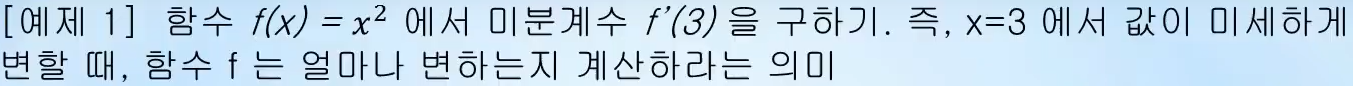


In [13]:
def my_func1(x):
    
    return x**2

def numerical_derivative(f, x):
    
    delta_x = 1e-4
    
    return (f(x+delta_x) - f(x-delta_x)) / (2*delta_x)

result = numerical_derivative(my_func1, 3)

print("result ==", result)

result == 6.000000000012662


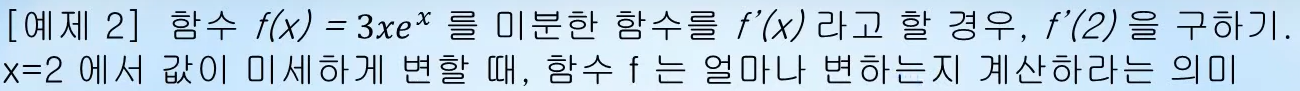

In [ ]:
print("3*exp(2) + 3*2*exp(2) == ", end='')


print(3*np.exp(2) + 3*2*np.exp(2))

3*exp(2) + 3*2*exp(2) == 66.50150489037586


In [17]:
import numpy as np

def my_func2(x):
    
    return 3*x*(np.exp(x))

def numerical_derivative(f, x):
    
    delta_x = 1e-4
    
    return  (f(x + delta_x) - f(x - delta_x)) / (2*delta_x)

result = numerical_derivative(my_func2, 2)

print("result ==", result)

result == 66.50150507518049


In [16]:
import numpy as np

def my_func2(x):
    
    return 3*x*(np.exp(x))

def numerical_derivative(f, x):
    
    delta_x = 1e-4
    
    return  (f(x + delta_x) - f(x)) / (delta_x)

result = numerical_derivative(my_func2, 2)

print("result ==", result)

result == 66.50593850892506


In [ ]:
#함수 𝑓 ( 𝑥 ) = sin ⁡ ( 𝑥 ) ⋅ 𝑒^𝑥 의 도함수를 𝑓 ′ ( 𝑥 ) 라 할 때, 𝑓 ′ ( 0 ) 을 구하시오
def func(x):
   return np.sin(x)*np.exp(x)

def numerical_diff(f, x):
    
    delta_x = 1e-4
    
    return (f(x+delta_x)+f(x))/delta_x

print(numerical_diff(func,0))

1.0001000033333334


# 수치미분 최종버전 - numerical derivative

실무에서는 입력변수가 하나가 아닌 하나이상인 다변수 함수의 경우가 많다.  

입력 변수가 하나 이상인 다 변수 함수의 경우, 입력변수는 서로 독립적이기 때문에 수치미분 또한 변수의 개수만큼 개별적으로 계산 하여야함

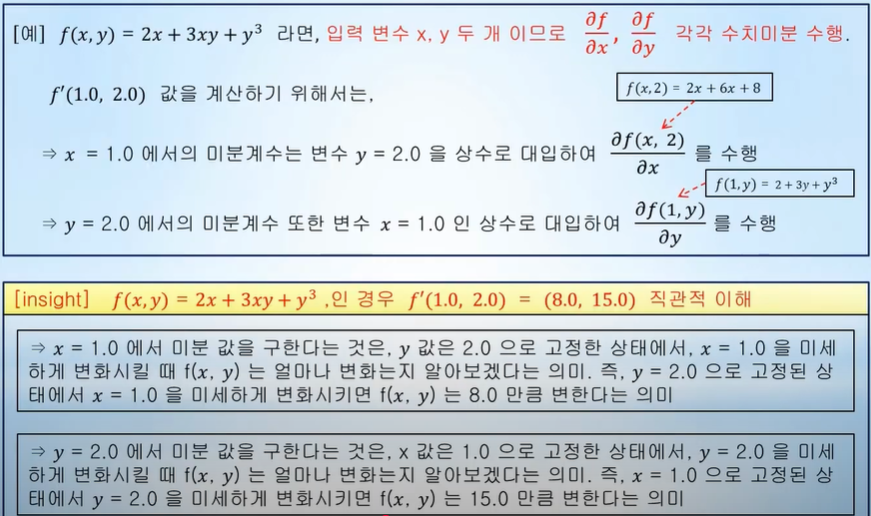

In [ ]:
import numpy as np

def numerical_derivative(f, x):
    delta_x = 1e-4
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    
    while not it.finished:
        idx = it.multi_index
        
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + delta_x
        fx1 = f(x) #f(x+delta_x)
        
        x[idx] = tmp_val - delta_x
        fx2 = f(x) #f(x-delta_x)
        
        grad[idx] = (fx1 - fx2) / (2*delta_x)
        
        x[idx] = tmp_val
        it.iternext()
        
    return grad

### 수치 미분 예제 - 1변수함수 f(x) = x^2, f'(3.0)

In [32]:
import numpy as np

def numerical_derivative(f, x):
    delta_x = 1e-4
    grad = np.zeros_like(x)
    
    print("debug 1. initial input variable =", x)
    print("debug 2. initial grad =", grad)
    print("======================================")
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    
    while not it.finished:
        idx = it.multi_index
        
        print("debug 3. idx = ", idx, ", x[idx] = ", x[idx])
        
        tmp_value = x[idx]
        x[idx] = tmp_value + delta_x
        fx1 = f(x)
        
        x[idx] = tmp_value - delta_x
        fx2 = f(x)
        
        grad[idx] = (fx1 - fx2) / (2*delta_x)
        
        print("debug 4. grad[idx] =", grad[idx])
        print("debug 5. grad =", grad)
        
        x[idx] = tmp_value
        it.iternext()
        
    return grad

def func(input_obj):
    
    x = input_obj[0]
    
    return x**2

numerical_derivative(func, np.array([3.0]))
        

debug 1. initial input variable = [3.]
debug 2. initial grad = [0.]
debug 3. idx =  (0,) , x[idx] =  3.0
debug 4. grad[idx] = 6.000000000012662
debug 5. grad = [6.]


array([6.])

### 편미분 예제 = 2변수 함수 f(x,y) = 2x+3xy+y^3 , f'(1.0,2.0) 

In [43]:
def numerical_derivative(f, x):
    delta_x = 1e-4
    grad = np.zeros_like(x)
    
    print("debug 1. initial input variable =", x)
    print("debug 2. initial grad =", grad)
    print("======================================")
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    
    while not it.finished:
        idx = it.multi_index
        
        print("debug 3. idx = ", idx, ", x[idx] = ", x[idx])
        
        tmp_value = x[idx]
        x[idx] = tmp_value + delta_x
        fx1 = f(x)
        
        x[idx] = tmp_value - delta_x
        fx2 = f(x)
        
        grad[idx] = (fx1 - fx2) / (2*delta_x)
        
        print("debug 4. grad[idx] =", grad[idx])
        print("debug 5. grad =", grad)
        print("======================================")
        x[idx] = tmp_value
        it.iternext()
        
    return(grad)

def func2(input_obj):
    
    x = input_obj[0]
    y = input_obj[1]
    
    return((2*x)+(3*x*y)+np.power(y,3))


input = np.array([1.0, 2.0])
numerical_derivative(func2, input)

debug 1. initial input variable = [1. 2.]
debug 2. initial grad = [0. 0.]
debug 3. idx =  (0,) , x[idx] =  1.0
debug 4. grad[idx] = 7.999999999990237
debug 5. grad = [8. 0.]
debug 3. idx =  (1,) , x[idx] =  2.0
debug 4. grad[idx] = 15.000000010019221
debug 5. grad = [ 8.         15.00000001]


array([ 8.        , 15.00000001])

### 편미분 예제 = 4변수 함수 f(w,x,y,z) = wx + xyz + 3w +zy^2 , f'(1.0,2.0,3.0,4.0) 

In [64]:
import numpy as np

def numerical_derivative(f, x):
    delta_x = 1e-4
    grad = np.zeros_like(x)
    
    print("debug 1. initial input variable =", x)
    print("debug 2. initial grad =", grad)
    print("======================================")
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    
    while not it.finished:
        idx = it.multi_index
        
        print("debug 3. idx = ", idx, ", x[idx] = ", x[idx])
        
        tmp_value = x[idx]
        x[idx] = float(tmp_value) + delta_x
        fx1 = f(x)
        
        x[idx] = tmp_value - delta_x
        fx2 = f(x)
        
        grad[idx] = (fx1 - fx2) / (2*delta_x)
        
        print("debug 4. grad[idx] =", grad[idx])
        print("debug 5. grad =", grad)
        print("======================================")
        x[idx] = tmp_value
        it.iternext()
        
    return(grad)

def func3(input_obj):
    
    w = input_obj[0, 0]
    x = input_obj[0, 1]
    y = input_obj[1, 0]
    z = input_obj[1, 1]
    
    funct = ( w*x + x*y*z + 3*w + z*np.power(y,2) )
    return(funct)
    
input = np.array([[1.0, 2.0], [3.0, 4.0]])
numerical_derivative(func3, input)

debug 1. initial input variable = [[1. 2.]
 [3. 4.]]
debug 2. initial grad = [[0. 0.]
 [0. 0.]]
debug 3. idx =  (0, 0) , x[idx] =  1.0
debug 4. grad[idx] = 5.000000000023874
debug 5. grad = [[5. 0.]
 [0. 0.]]
debug 3. idx =  (0, 1) , x[idx] =  2.0
debug 4. grad[idx] = 13.00000000000523
debug 5. grad = [[ 5. 13.]
 [ 0.  0.]]
debug 3. idx =  (1, 0) , x[idx] =  3.0
debug 4. grad[idx] = 32.00000000006753
debug 5. grad = [[ 5. 13.]
 [32.  0.]]
debug 3. idx =  (1, 1) , x[idx] =  4.0
debug 4. grad[idx] = 15.000000000000568
debug 5. grad = [[ 5. 13.]
 [32. 15.]]


array([[ 5., 13.],
       [32., 15.]])